In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              roc_curve, precision_recall_curve, f1_score)
from xgboost import XGBClassifier

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)
pd.set_option('display.max_columns', None)

RANDOM_STATE = 42


C:\Users\tanga\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Load and Clean data

In [4]:
df = pd.read_csv(' WA_Fn-UseC_-Telco-Customer-Churn.csv.csv')
print(f"Shape: {df.shape}")
df.head()


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# TotalCharges is read as text because 11 brand-new customers (tenure=0) have blank values.
# Convert to numeric and fill those with 0 (no charges accrued yet).
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"Rows with missing TotalCharges (all tenure=0): {df['TotalCharges'].isnull().sum()}")
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Drop the ID column - it's not predictive
df = df.drop(columns=['customerID'])

# Encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(df.isnull().sum().sum(), "missing values remaining")
df.describe()


Rows with missing TotalCharges (all tenure=0): 11
0 missing values remaining


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304,0.265370
std,0.368612,24.559481,30.090047,2266.794470,0.441561
min,0.000000,0.000000,18.250000,0.000000,0.000000
25%,0.000000,9.000000,35.500000,398.550000,0.000000
50%,0.000000,29.000000,70.350000,1394.550000,0.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


## Exploratory analysis

Overall churn rate: 26.5%


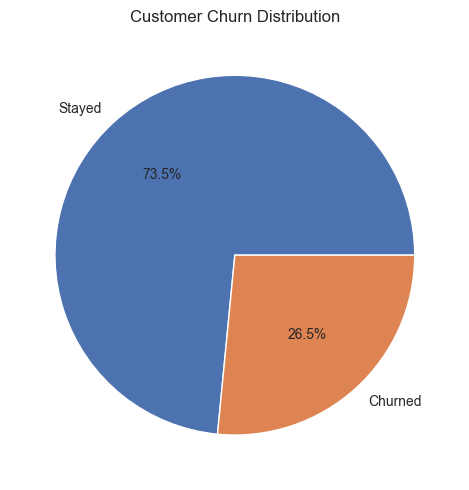

In [6]:
churn_rate = df['Churn'].mean()
print(f"Overall churn rate: {churn_rate:.1%}")

fig, ax = plt.subplots(figsize=(5,5))
df['Churn'].value_counts().rename({0:'Stayed', 1:'Churned'}).plot(
    kind='pie', autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'], ax=ax, ylabel='')
ax.set_title('Customer Churn Distribution')
plt.tight_layout()
plt.show()


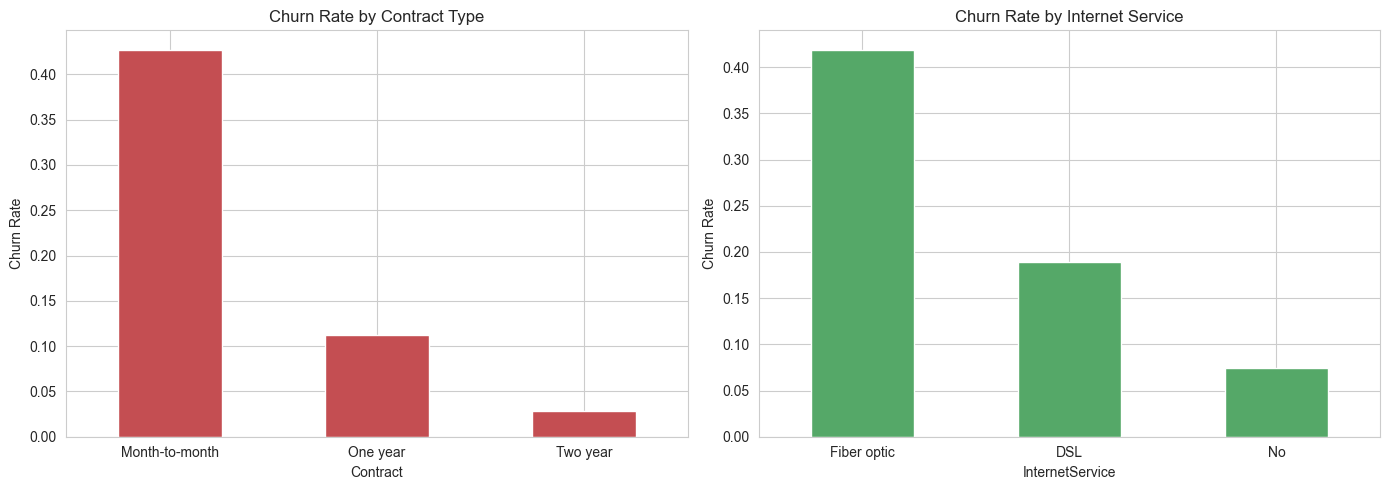

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64

InternetService
Fiber optic    0.418928
DSL            0.189591
No             0.074050
Name: Churn, dtype: float64


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn by contract type
contract_churn = df.groupby('Contract')['Churn'].mean().sort_values(ascending=False)
contract_churn.plot(kind='bar', ax=axes[0], color='#C44E52')
axes[0].set_title('Churn Rate by Contract Type')
axes[0].set_ylabel('Churn Rate')
axes[0].tick_params(axis='x', rotation=0)

# Churn by internet service
internet_churn = df.groupby('InternetService')['Churn'].mean().sort_values(ascending=False)
internet_churn.plot(kind='bar', ax=axes[1], color='#55A868')
axes[1].set_title('Churn Rate by Internet Service')
axes[1].set_ylabel('Churn Rate')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(contract_churn)
print()
print(internet_churn)


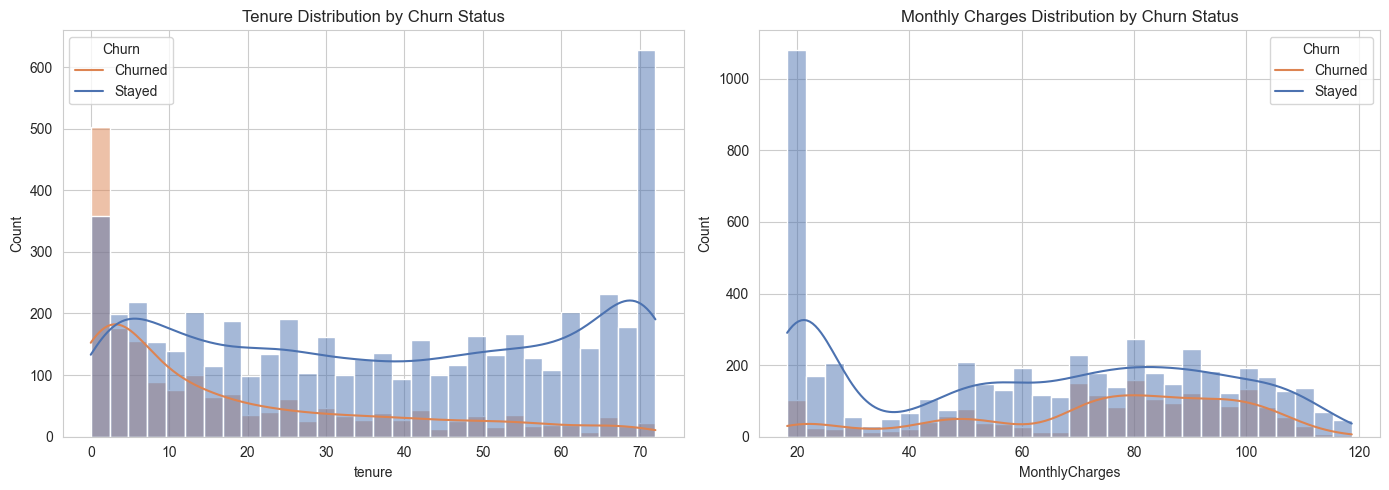

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True, ax=axes[0],
             palette={0:'#4C72B0', 1:'#DD8452'})
axes[0].set_title('Tenure Distribution by Churn Status')
axes[0].legend(title='Churn', labels=['Churned', 'Stayed'])

sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30, kde=True, ax=axes[1],
             palette={0:'#4C72B0', 1:'#DD8452'})
axes[1].set_title('Monthly Charges Distribution by Churn Status')
axes[1].legend(title='Churn', labels=['Churned', 'Stayed'])

plt.tight_layout()
plt.show()


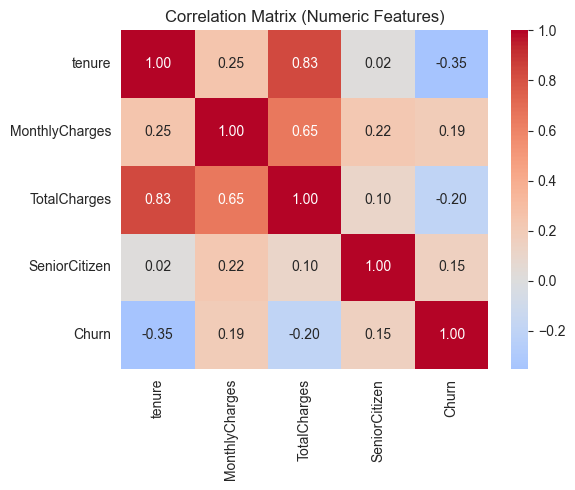

In [9]:
# Quick correlation check among numeric features and churn
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn']
corr = df[numeric_cols].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix (Numeric Features)')
plt.tight_layout()
plt.show()


## Feature Engineering

In [10]:
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
              'Contract', 'PaymentMethod']

df_model = df.copy()

# Binary columns: map Yes/No -> 1/0 (gender mapped Female=1 to keep things numeric/consistent)
df_model['gender'] = df_model['gender'].map({'Male': 0, 'Female': 1})
for col in ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']:
    df_model[col] = df_model[col].map({'Yes': 1, 'No': 0})

# Multi-category columns: one-hot encode
df_model = pd.get_dummies(df_model, columns=multi_cols, drop_first=True)

print(f"Final feature count: {df_model.shape[1] - 1}")
df_model.head()


Final feature count: 30


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,1,29.85,29.85,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,0,0,0,0,34,1,0,56.95,1889.50,0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,0,0,0,0,2,1,1,53.85,108.15,1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,0,0,0,0,45,0,0,42.30,1840.75,0,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,1,0,0,0,2,1,1,70.70,151.65,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


## Train - Test split

In [11]:
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
print(f"Train churn rate: {y_train.mean():.1%} | Test churn rate: {y_test.mean():.1%}")

# Scale numeric features for the logistic regression model
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])


Train: 5634 rows | Test: 1409 rows
Train churn rate: 26.5% | Test churn rate: 26.5%


## Model training

In [12]:
models = {}

# Logistic Regression
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)
models['Logistic Regression'] = (log_reg, X_test_scaled)

# Random Forest
rf = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced',
                             random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
models['Random Forest'] = (rf, X_test)

# XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                     scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE,
                     eval_metric='logloss')
xgb.fit(X_train, y_train)
models['XGBoost'] = (xgb, X_test)

print("All three models trained.")


All three models trained.


## Model comparison and evaluation

In [32]:
results = []
roc_data = {}

for name, (model, X_te) in models.items():
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    auc = roc_auc_score(y_test, y_prob)
    f1 = f1_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)

    results.append({
        'Model': name,
        'Accuracy': report['accuracy'],
        'Precision (Churn)': report['1']['precision'],
        'Recall (Churn)': report['1']['recall'],
        'F1 (Churn)': f1,
        'ROC-AUC': auc
    })

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_data[name] = (fpr, tpr, auc)

results_df = pd.DataFrame(results).set_index('Model').round(3)
results_df


,Accuracy,Precision (Churn),Recall (Churn),F1 (Churn),ROC-AUC
Model,,,,,
Logistic Regression,0.739,0.505,0.783,0.614,0.842
Random Forest,0.749,0.517,0.791,0.626,0.844
XGBoost,0.752,0.521,0.791,0.628,0.839


## Churn drivers (Feature importance)

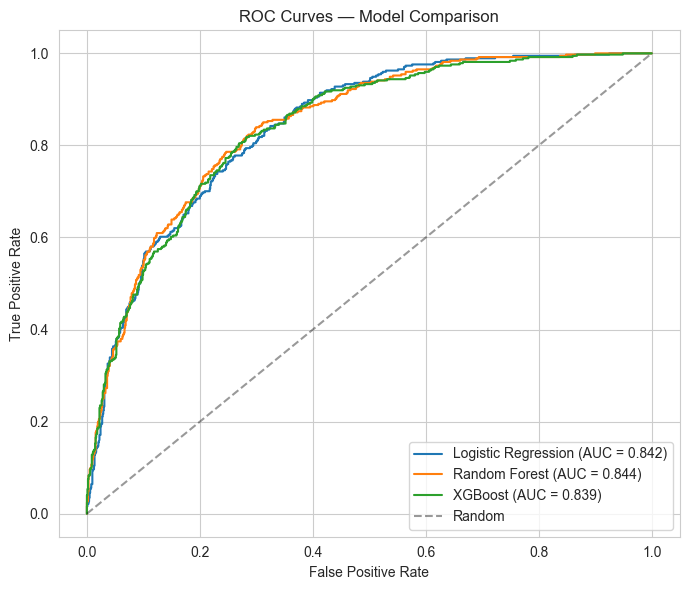

In [14]:
plt.figure(figsize=(7,6))
for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")
plt.plot([0,1],[0,1], 'k--', alpha=0.4, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison')
plt.legend()
plt.tight_layout()
plt.show()


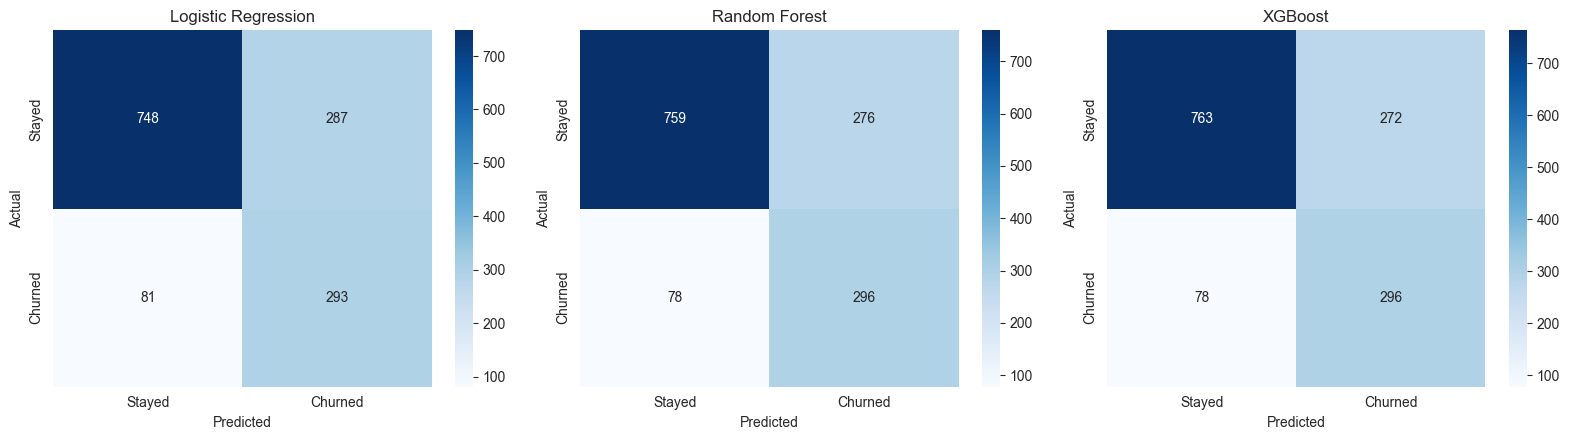

In [15]:
# Confusion matrices for all three, side by side
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, (model, X_te)) in zip(axes, models.items()):
    y_pred = model.predict(X_te)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Stayed','Churned'], yticklabels=['Stayed','Churned'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


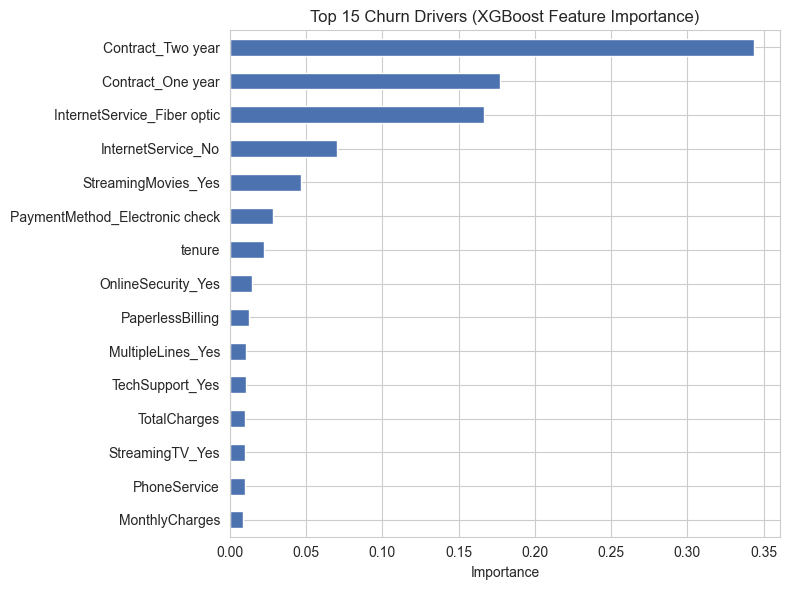

In [16]:
importances = pd.Series(xgb.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
top_features.sort_values().plot(kind='barh', color='#4C72B0')
plt.title('Top 15 Churn Drivers (XGBoost Feature Importance)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


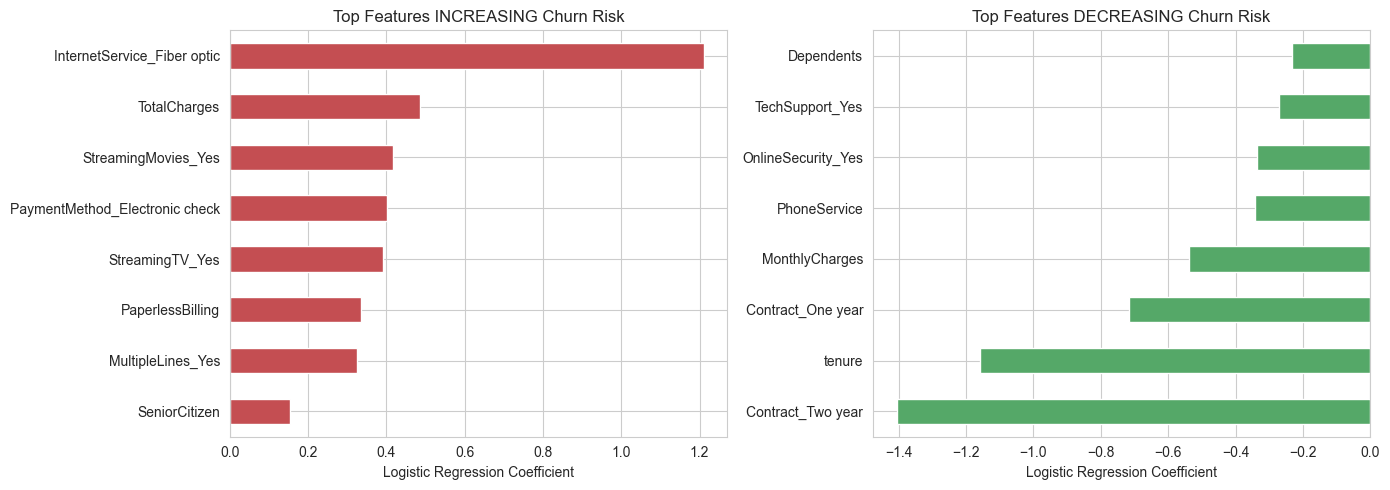

In [17]:
coefs = pd.Series(log_reg.coef_[0], index=X_train.columns)
top_pos = coefs.sort_values(ascending=False).head(8)   # increase churn odds
top_neg = coefs.sort_values().head(8)                    # decrease churn odds

fig, axes = plt.subplots(1, 2, figsize=(14,5))
top_pos.sort_values().plot(kind='barh', ax=axes[0], color='#C44E52')
axes[0].set_title('Top Features INCREASING Churn Risk')
axes[0].set_xlabel('Logistic Regression Coefficient')

top_neg.sort_values().plot(kind='barh', ax=axes[1], color='#55A868')
axes[1].set_title('Top Features DECREASING Churn Risk')
axes[1].set_xlabel('Logistic Regression Coefficient')

plt.tight_layout()
plt.show()


## Business recommendation

**Contract type is the single biggest lever.** Month-to-month customers churn at far higher rates than one- or two-year contract holders. Incentivizing a switch to longer commitments (even a modest discount) is likely the highest-leverage retention action available.

**Early tenure is the danger zone.** Churn risk is concentrated in the first several months. A structured onboarding or check-in program in months 1–3 could catch dissatisfaction before it turns into a cancellation.

**Fiber-optic customers churn more despite paying more.** This is usually a signal of a service-quality or pricing-perception issue rather than a customer-fit issue — worth investigating with a satisfaction survey or support-ticket analysis for that segment specifically.

**Suggested next step:** score the current customer base with this model, rank by predicted churn probability, and route the top-decile at-risk customers to a retention team — focusing first on month-to-month, low-tenure, fiber customers, since that's where the model and the EDA agree the risk concentrates.